In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_squared_error

from sklearn.model_selection import cross_val_score  , KFold , cross_val_predict


In [113]:
# We load our dataset and remove only the student_id column as its the one which is less important

student_df = pd.read_csv(r"C:\Users\Kxbuga\Desktop\student-performance-ml\data\Student_performance_data _.csv").drop(['StudentID'] , axis = 1)

# we display the 1st 5 rows

student_df.head()


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [114]:
# We impliment regression model

# The syntax we follow is the same as that of classification model

# 1. We import our model
# 2. Instantiate our model
# 3. Fit our data to the model
# 4. predict

In [115]:
# Simple notes to be able to remember about regression model

# It is a supervised model where we predict the value of dependent(target) continous variable based on a single indipendent or multiple indipendent(features) variables.

# We fit a line of best fit which is usually of the format y = ax + b where:    
            # y is the target ,
            # x is the feature , 
            # b is the intercept(where the line cuts the y axis when x is = 0)
            # a is the slope(for every single change in x how much does y change)

# NB Since we are using a single feature this is a SIMPLE REGRESSION MODEL

# NB If we use multiple features it will be a MULTIPLE REGRESSION MODEL

# IN MULTIPLE REGRESSION MODEL THE LINE WILL BE OF THE FORM: Y = a1x1 + a2x2 + a3x3........anxn + b 

# The line of best fit is the one that best optimizes the slope value and the y intercept value such that the predicted y values are as close as possible to the actual data points

# SO HOW DO WE FIND THE BEST LINE???

# To find the best-fit line, we use a method called Least Squares. The idea behind this method is to minimize the sum of squared differences between the actual values (data points) and the predicted values from the line. These differences are called residuals.


# SOME ASSUMPTIONS OF THE REGRESSION MODEL

# lINEARITY - The relationship between the features and the target variable is a straight line
# Indipendence of Errors - The errors of the predictions should not affect each other
# No Multicolluniarity - The features should not be too closely related to each other. 
# Constant varaince




# SO THE NEXT QUESTION THAT ARISES SINCE WE HAVE THE REGRESSION LINE THAT IS THE BEST HOW FAR IS IT FROM THE ACTUAL VALUES. INTRODUCES A CONCEPT WE CALL COST FUNCTION

# This is measures how far the predicted values are from the actual values to help us reduce the errors. COMMON USED: Mean Squared error. Meaures the average of squared differences between the actual and predicted values

# After getting the cost how do we minimse the cost function??? WE USE GRADIENT DESCENT


# GRADIENT DESCENT

# This is an optimization technique used to train our regression model by minimizing the prediction error

# STEPS WE FOLLOW:
# 1. Pick random values(for the slope and intercept)
# 2. Calculate the error between the predicted and the actual values
# 3. Find how much each parameter contributes to the error
# 4. Update the parameters in the direction that reduces the error.
# 5. Repeat until the error is as small as possible.

In [116]:
# SOME EVALUATION METRICS USED TO CALCULATE THE STRENGTH OF A REGRESSION MODEL

# Mean squared error
# Mean absolute error
# R- squared

In [117]:
# REGULARIZATION
# This is a technique to reduce overfitting and underfitting

# Overfitting = when our model learns too much includeing noise
    # It gets a 100% on the training data but fails miserably on the new , unseen data
# underfitting = when our model learns too little
    # It performs poorly on training and new data because it has even learnt the basics yet


# SOME REGULARIZATION TECHNIQUES

# Lasso , ridge and elastic Net regression

In [118]:
# IMPLIMENTING SIMPLE LINEAR REGRESSION

#  x = study time weekly
#  y = gpa

In [119]:
X = student_df.iloc[: , 4].values
print(f"The shape of x = {X.shape}")

y = student_df.iloc[: , -2].values
print(f"The shape of y = {y.shape}")

The shape of x = (2392,)
The shape of y = (2392,)


In [120]:
# We need to reshape x as it should be in multi array

X = X.reshape(-1 , 1)
print(f"The shape of x = {X.shape}")

The shape of x = (2392, 1)


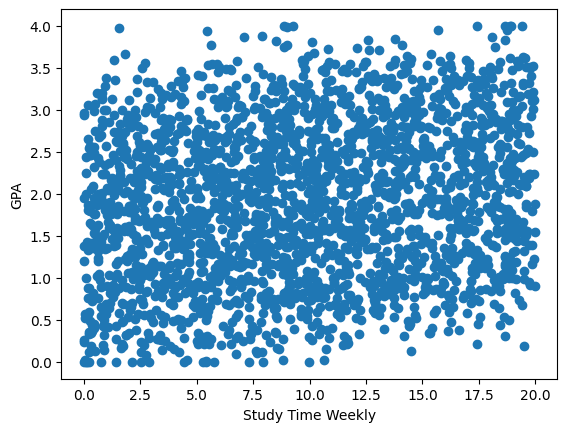

In [121]:
# We plot and see if the relationship we have of study time weekly and gpa is linear

plt.scatter(X , y)
plt.ylabel("GPA")
plt.xlabel('Study Time Weekly')
plt.show()

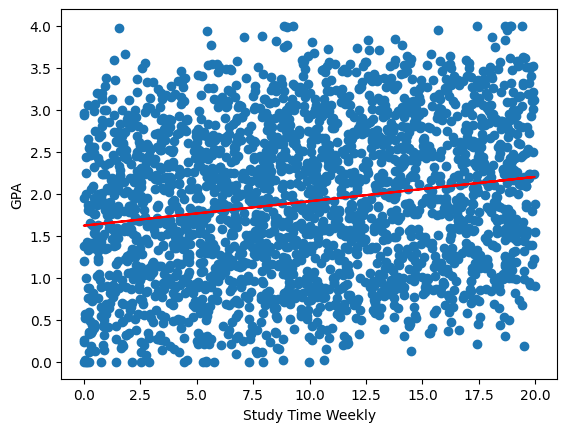

In [122]:
# Fit a regression model

reg = LinearRegression() # instantiate our model
reg.fit(X , y) # fit our model
predictions = reg.predict(X) # predict using our x values(study time weekly)

# plot our scatter model and regression line

plt.scatter(X , y)
plt.plot(X , predictions , color = 'red') # we plot the x values(study time weekly) against the predictions(y values)
plt.ylabel("GPA")
plt.xlabel('Study Time Weekly')
plt.show()

In [123]:
# MULTIPLE LINEAR REGRESSION(WE USE MANY FEATURES)

X_features = student_df.iloc[: , [4 , 5 ,6, 7 ,8 ,9 ,10 ,11]].values
X_features

y_features = student_df.iloc[: , 12].values
y_features

# No need to reshape

array([2.92919559, 3.04291483, 0.11260225, ..., 1.14233288, 1.80329676,
       2.14001388], shape=(2392,))

In [124]:
X_train , X_test , y_train , y_test = train_test_split(X_features , y_features , test_size = 0.3 , random_state = 42)

reg_all = LinearRegression() 
reg_all.fit(X_train , y_train)
y_pred = reg_all.predict(X_test)

print('Predictions: {} , Actual Values{}'.format(y_pred[:2] , y_test[:2]))

Predictions: [1.45797189 2.91626639] , Actual Values[1.42772438 3.11735443]


In [125]:
# Calculate the r-squared value

# How far is our target values from the linear regression line explained by our features
#  It is always in the range of 0 to 1. In general, the better the model matches the data, the greater the R-squared number.

reg_all.score(X_test , y_test) # higher the value more accurate

0.9554921306800218

In [126]:
# ROOT MEAN SQAURED ERROR(RMSE)

# Square root of the residuals variance is RMSE. It describes how well the observed data points match the expected values or the model's absolute fit to the data.

root_mean_squared_error(y_test , y_pred)

0.1935900598331864

In [127]:
# Mean squared error

# Measures the average squared difference between actual and predicted values to avoid cancellation of errors.

mean_squared_error(y_pred , y_test)

0.03747711126621668

In [128]:
# CROSS_VALIDATION

# This concept was introduced to solve the disadvantage of the R SQUARED 

# R squared behaviour is dependent on the value of the test data.Like how much data we set aside. So if we were to change rhe value of the testdata by default which is 0.3 the value of the rsquared would change

#`How cross validation solves thsi


# Cross validation splits our data into folds or splits 
# But before splitting we usually shuffle to reduce biasness. EG: IF our data is sort based on gpa maybe highest gpa to lowest gpa , your 1st fold mightt only see failing students which will ruin your model

# So assuminf we have 4 folds : k1 , k2 ,k3 , k4 
# During our 1st trainig we set aside k1 as the test and fit the remaining kfolds into our data

# During the second run we set aside k2 as the test and the rest of the kfolds into our training data

# By doing this we make sure that each data point is used in both testing and training

# By doing this we solve the dependency of rsquared on the test data.

In [129]:
# this is what we import

# from sklearn.model_selection import cross_val_score  , KFold


# We specify the number of folds and the reshufflling also the random state

kf = KFold(n_splits = 6 , shuffle = True , random_state = 42 )

# instantiate our model

reg_cross = LinearRegression()

# fit our model , the k

cv_results = cross_val_score(reg_cross , X_features , y_features ,  cv = kf) #syntax matters its our model , value of x , y then our cv

In [130]:
# Should return and array of 6 predictions
print(cv_results)

[0.95446692 0.95598009 0.95291807 0.93971967 0.95606101 0.95847207]


In [131]:
# We can perform simple arithmetic operations such as mean , standard devaition and the 95% confidence interval

print(f"Mean of rsquared = {np.mean(cv_results)}")
print(f"Standard Deaviation of rsquared = {np.std(cv_results)}")
print(f"95% Confidence Interval = {np.quantile(cv_results , [0.025 , 0.0975])}")

Mean of rsquared = 0.9529363062008952
Standard Deaviation of rsquared = 0.0061467574437505754
95% Confidence Interval = [0.94136947 0.94615389]


In [134]:
y_pred_cv = cross_val_predict(reg_cross , X_features , y_features , cv = kf)

print('CV Predictions: {}, Actual Values: {}'.format(y_pred_cv[:2], y_features[:2]))

CV Predictions: [3.07802145 3.11499371], Actual Values: [2.92919559 3.04291483]


In [ ]:
# FINAL TAKEAWAY

# ADVISABLE TO USE train_test_split in combination with cross validation(HYBRID)


# 1. wE SPLIT OUR DATA INTO TEST AND TRAIN DATA

# 2 PERFOM CROSS VALIDATION ON THE KFOLDS ONLY AND GET THE MEAN FOR EACH RSQAURED FOLD

# 3. FIT OUR X_TRAIN AND Y_TRAIN DATA INTO THE MODEL IE:model.fit()

# 4. CALCULATE THE FINAL RSQUARED VALUE TO SEE HOW FAR IT DEVIATES FROM THE MEAN OF THE CROSS VALIDATION








# when we use train_test_split alone when we calculate the rsquared value the value we get we don't really know if the value is trustworth or not

# Imagine if we get a high rsqaured value we don't really know if the x and y values we provided are easy to predict or our model is accurate

# when we have cross_validation its like areference. In cross validation depending on the number of splits we will have a range of r squared values

# We calculate the mean to get where the rsqaured values range

# Then we fit our model to the training data and calculate the rsquared value we will be checking the value we have gotten how far it devaiates from the mean


# if we have a low Final value and mean is high = overfitting(Our model is dependent on the training data it hasn't learnt the pattern) SOLUTION = Regularization

# if we have a moderate final value that is it is within the same range as the mean value of the cross validation = WE CAN TRUST THE MODEL IN REAL ENVIRONMENT = ROBUST

# If the final rsqared value is high = We may need to test again since we are not sure if the values we provide are easy to predict

# WHEN TO STOP

# when the final value and the mean value are within close range